In [6]:
!pip install --upgrade pip
!pip install ultralytics roboflow pandas matplotlib pyyaml

  Using cached pip-26.1.2-py3-none-any.whl.metadata (4.6 kB)
Using cached pip-26.1.2-py3-none-any.whl (1.8 MB)


ERROR: To modify pip, please run the following command:
C:\Users\Arjun\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from roboflow import Roboflow
import os, shutil

API_KEY = "lCakLx5MAemDQu7MOe0K"
WORKSPACE = "arjuns-workspace-utjh6"
PROJECT = "data-science-3-tlvei"
VERSION = 1

LOCAL_DATASET_ROOT = r"C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw"

rf = Roboflow(api_key=API_KEY)
project = rf.workspace(WORKSPACE).project(PROJECT)
version = project.version(VERSION)

try:
    dataset = version.download("yolo26")

print("Downloaded to:", dataset.location)

if os.path.abspath(dataset.location) != os.path.abspath(LOCAL_DATASET_ROOT):
    if os.path.exists(LOCAL_DATASET_ROOT):
        shutil.rmtree(LOCAL_DATASET_ROOT)
    shutil.copytree(dataset.location, LOCAL_DATASET_ROOT)

print("Final dataset root:", LOCAL_DATASET_ROOT)

loading Roboflow workspace...
loading Roboflow project...
Downloaded to: c:\Users\Arjun\Desktop\Work\2025-2026\3rd Term\Data Science 3 CSS182-03\Data-Science-3-1
Final dataset root: C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw


In [8]:
import os, glob, random, shutil
random.seed(42)

root = r"C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw"
train_img = os.path.join(root, "train", "images")
train_lbl = os.path.join(root, "train", "labels")
valid_img = os.path.join(root, "valid", "images")
valid_lbl = os.path.join(root, "valid", "labels")

os.makedirs(valid_img, exist_ok=True)
os.makedirs(valid_lbl, exist_ok=True)

# current counts
train_existing = glob.glob(os.path.join(train_img, "*"))
valid_existing = glob.glob(os.path.join(valid_img, "*"))
print("Before split -> train:", len(train_existing), "valid:", len(valid_existing))

if len(valid_existing) == 0:
    imgs = []
    for ext in ("*.jpg", "*.jpeg", "*.png", "*.bmp", "*.webp"):
        imgs.extend(glob.glob(os.path.join(train_img, ext)))
    imgs = sorted(imgs)

    if len(imgs) == 0:
        raise RuntimeError("No images found in train/images. Check dataset path.")

    n_valid = max(1, int(len(imgs) * 0.2))
    n_valid = min(n_valid, len(imgs))
    selected = set(random.sample(imgs, n_valid))

    moved = 0
    missing_labels = 0

    for ip in selected:
        name = os.path.basename(ip)
        stem = os.path.splitext(name)[0]
        lp = os.path.join(train_lbl, f"{stem}.txt")

        shutil.move(ip, os.path.join(valid_img, name))
        moved += 1

        if os.path.exists(lp):
            shutil.move(lp, os.path.join(valid_lbl, f"{stem}.txt"))
        else:
            missing_labels += 1

    print(f"Moved {moved} images to valid.")
    print(f"Missing labels among moved images: {missing_labels}")
else:
    print("Valid split already exists. Skipping split.")

print("After split -> train:", len(glob.glob(os.path.join(train_img, '*'))))
print("After split -> valid:", len(glob.glob(os.path.join(valid_img, '*'))))

Before split -> train: 2739 valid: 0
Moved 547 images to valid.
Missing labels among moved images: 0
After split -> train: 2192
After split -> valid: 547


In [9]:
import os, yaml

root = r"C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw"
yaml_path = os.path.join(root, "data_fixed.yaml")

data = {
    "path": root.replace("\\", "/"),
    "train": "train/images",
    "val": "valid/images",
    "names": {
        0: "jeepneys",
        1: "bus",
        2: "car",
        3: "motorcycle",
        4: "trucks",
        5: "vans"
    }
}

with open(yaml_path, "w", encoding="utf-8") as f:
    yaml.dump(data, f, sort_keys=False, allow_unicode=True)

print("Saved:", yaml_path)
with open(yaml_path, "r", encoding="utf-8") as f:
    print(f.read())

Saved: C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\data_fixed.yaml
path: C:/Users/Arjun/Documents/yolo_vehicle_project/dataset_raw
train: train/images
val: valid/images
names:
  0: jeepneys
  1: bus
  2: car
  3: motorcycle
  4: trucks
  5: vans



In [10]:
from ultralytics import YOLO
import os

yaml_path = r"C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\data_fixed.yaml"
PROJECT_DIR = r"C:\Users\Arjun\Documents\yolo_vehicle_project\outputs"
os.makedirs(PROJECT_DIR, exist_ok=True)

experiments = [
    {"name":"model_A", "model":"yolo26n.pt", "epochs":25, "imgsz":640, "optimizer":"AdamW", "batch":4,  "lr0":0.01},
    {"name":"model_B", "model":"yolo26n.pt", "epochs":30, "imgsz":640, "optimizer":"SGD",   "batch":20, "lr0":0.001},
    {"name":"model_C", "model":"yolo26n.pt", "epochs":40, "imgsz":640, "optimizer":"auto",  "batch":-1, "lr0":0.0001},
]

for exp in experiments:
    model = YOLO(exp["model"])
    model.train(
        data=yaml_path,
        epochs=exp["epochs"],
        imgsz=exp["imgsz"],
        optimizer=exp["optimizer"],
        batch=exp["batch"],
        lr0=exp["lr0"],
        project=PROJECT_DIR,
        name=exp["name"],
        pretrained=True,
        verbose=True
    )

Ultralytics 8.4.89  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\data_fixed.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dis=6.0, distill_model=None, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo26n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=model_A, nbs=64, nms=False, opset=No

In [20]:
import os, pandas as pd
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

PROJECT_DIR = r"C:\Users\Arjun\Documents\yolo_vehicle_project\outputs"
yaml_path = r"C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\data_fixed.yaml"

experiments = [
    {"name":"model_A", "model":"yolo26n.pt", "epochs":25, "imgsz":640, "optimizer":"AdamW", "batch":4,  "lr0":0.01},
    {"name":"model_B", "model":"yolo26n.pt", "epochs":30, "imgsz":640, "optimizer":"SGD",   "batch":20, "lr0":0.001},
    {"name":"model_C", "model":"yolo26n.pt", "epochs":40, "imgsz":640, "optimizer":"auto",  "batch":-1, "lr0":0.0001},
]

final_rows = []
for exp in experiments:
    csv_path = os.path.join(PROJECT_DIR, exp["name"], "results.csv")
    df = pd.read_csv(csv_path)
    row = df.iloc[-1].to_dict()
    row["Model Run"] = exp["name"]
    final_rows.append(row)

final_epoch_df = pd.DataFrame(final_rows)
final_epoch_df.to_csv(os.path.join(PROJECT_DIR, "deliverable_final_epoch_results.csv"), index=False)

hyper_df = pd.DataFrame(experiments)[["name","model","epochs","imgsz","optimizer","batch","lr0"]]
hyper_df = hyper_df.rename(columns={"name":"Model Run", "lr0":"Learning Rate"})
hyper_df.to_csv(os.path.join(PROJECT_DIR, "deliverable_hyperparameters_table.csv"), index=False)

metrics_rows = []
for exp in experiments:
    best_w = os.path.join(PROJECT_DIR, exp["name"], "weights", "best.pt")
    m = YOLO(best_w).val(data=yaml_path, imgsz=640, verbose=False)

    p = float(m.box.mp)
    r = float(m.box.mr)
    map50 = float(m.box.map50)
    f1 = 2 * p * r / (p + r + 1e-9)

    metrics_rows.append({
        "Model Run": exp["name"],
        "mAP50": map50,
        "Precision": p,
        "Recall": r,
        "F1 Score": f1
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values("mAP50", ascending=False)
metrics_df.to_csv(os.path.join(PROJECT_DIR, "deliverable_metrics_table.csv"), index=False)

print("Saved deliverables in:", PROJECT_DIR)
print(final_epoch_df)
print(hyper_df)
print(metrics_df)

for exp in experiments:
    cm_path = os.path.join(PROJECT_DIR, exp["name"], "confusion_matrix.png")
    if os.path.exists(cm_path):
        img = mpimg.imread(cm_path)
        plt.figure(figsize=(7,7))
        plt.title(f"{exp['name']} Confusion Matrix")
        plt.imshow(img)
        plt.axis("off")
        plt.show()

Ultralytics 8.4.89  Python-3.11.9 torch-2.5.1+cu121 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO26n summary (fused): 122 layers, 2,376,006 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 714.5221.3 MB/s, size: 60.9 KB)
val: Scanning C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\valid\labels.cache... 547 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 547/547  0.0s
val: C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\valid\images\RawData_mp4-0083_jpg.rf.1ddd81d1d0344d2d2004ba6021f32edf.jpg: 1 duplicate labels removed
val: C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\valid\images\RawData_mp4-0090_jpg.rf.4b8c710ea68119412a1b71121afd7ccf.jpg: 1 duplicate labels removed
val: C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\valid\images\RawData_mp4-0118_jpg.rf.c68fe7947bded1b6dc053c4107dc3007.jpg: 1 duplicate labels removed
val: C:\Users\Arjun\Documents\yolo_vehicle_project\dataset_raw\valid\imag

<Figure size 700x700 with 1 Axes>

<Figure size 700x700 with 1 Axes>

<Figure size 700x700 with 1 Axes>

In [26]:
import pandas as pd

hyperparams = pd.DataFrame([
    {"Model": "Model A", "Model File": "yolo26n.pt", "Epochs": 25, "Image Size": 640, "Optimizer": "AdamW", "Batch Size": 4,  "Initial LR (lr0)": 0.01},
    {"Model": "Model B", "Model File": "yolo26n.pt", "Epochs": 30, "Image Size": 640, "Optimizer": "SGD",   "Batch Size": 20, "Initial LR (lr0)": 0.001},
    {"Model": "Model C", "Model File": "yolo26n.pt", "Epochs": 40, "Image Size": 640, "Optimizer": "auto",  "Batch Size": -1, "Initial LR (lr0)": 0.0001},
])
hyperparams

,Model,Model File,Epochs,Image Size,Optimizer,Batch Size,Initial LR (lr0)
0,Model A,yolo26n.pt,25,640,AdamW,4,0.0100
1,Model B,yolo26n.pt,30,640,SGD,20,0.0010
2,Model C,yolo26n.pt,40,640,auto,-1,0.0001


In [28]:
overall_metrics = pd.DataFrame([
    {"Model": "Model A", "Precision": 0.751, "Recall": 0.669, "mAP50": 0.727, "mAP50-95": 0.497},
    {"Model": "Model B", "Precision": 0.540, "Recall": 0.453, "mAP50": 0.461, "mAP50-95": 0.310},
    {"Model": "Model C", "Precision": 0.767, "Recall": 0.680, "mAP50": 0.745, "mAP50-95": 0.526},
])
overall_metrics["F1 Score"] = (2 * overall_metrics["Precision"] * overall_metrics["Recall"]) / (overall_metrics["Precision"] + overall_metrics["Recall"])
overall_metrics

,Model,Precision,Recall,mAP50,mAP50-95,F1 Score
0,Model A,0.751,0.669,0.727,0.497,0.707632
1,Model B,0.540,0.453,0.461,0.310,0.492689
2,Model C,0.767,0.680,0.745,0.526,0.720885


In [23]:
per_class = pd.DataFrame([
    {"Model":"Model A","Class":"jeepneys","Instances":480,"Precision":0.552,"Recall":0.588,"mAP50":0.545},
    {"Model":"Model A","Class":"car","Instances":279,"Precision":0.667,"Recall":0.527,"mAP50":0.608},
    {"Model":"Model A","Class":"trucks","Instances":8965,"Precision":0.691,"Recall":0.598,"mAP50":0.650},
    {"Model":"Model A","Class":"vans","Instances":4048,"Precision":0.532,"Recall":0.434,"mAP50":0.438},
    {"Model":"Model A","Class":"motorcycle","Instances":580,"Precision":0.420,"Recall":0.495,"mAP50":0.450},
    {"Model":"Model A","Class":"bus","Instances":1377,"Precision":0.500,"Recall":0.641,"mAP50":0.564},

    {"Model":"Model B","Class":"jeepneys","Instances":480,"Precision":0.000,"Recall":0.000,"mAP50":0.000},
    {"Model":"Model B","Class":"car","Instances":279,"Precision":1.000,"Recall":0.000,"mAP50":0.002},
    {"Model":"Model B","Class":"trucks","Instances":8965,"Precision":0.255,"Recall":0.548,"mAP50":0.333},
    {"Model":"Model B","Class":"vans","Instances":4048,"Precision":0.201,"Recall":0.191,"mAP50":0.099},
    {"Model":"Model B","Class":"motorcycle","Instances":580,"Precision":1.000,"Recall":0.000,"mAP50":0.003},
    {"Model":"Model B","Class":"bus","Instances":1377,"Precision":0.251,"Recall":0.099,"mAP50":0.087},

    {"Model":"Model C","Class":"jeepneys","Instances":480,"Precision":0.797,"Recall":0.710,"mAP50":0.779},
    {"Model":"Model C","Class":"car","Instances":279,"Precision":0.847,"Recall":0.767,"mAP50":0.837},
    {"Model":"Model C","Class":"trucks","Instances":8965,"Precision":0.772,"Recall":0.704,"mAP50":0.773},
    {"Model":"Model C","Class":"vans","Instances":4048,"Precision":0.697,"Recall":0.577,"mAP50":0.635},
    {"Model":"Model C","Class":"motorcycle","Instances":580,"Precision":0.755,"Recall":0.667,"mAP50":0.722},
    {"Model":"Model C","Class":"bus","Instances":1377,"Precision":0.732,"Recall":0.656,"mAP50":0.727},
])
per_class

,Model,Class,Instances,Precision,Recall,mAP50
0,Model A,jeepneys,480,0.552,0.588,0.545
1,Model A,car,279,0.667,0.527,0.608
2,Model A,trucks,8965,0.691,0.598,0.650
3,Model A,vans,4048,0.532,0.434,0.438
4,Model A,motorcycle,580,0.420,0.495,0.450
5,Model A,bus,1377,0.500,0.641,0.564
6,Model B,jeepneys,480,0.000,0.000,0.000
7,Model B,car,279,1.000,0.000,0.002
8,Model B,trucks,8965,0.255,0.548,0.333
9,Model B,vans,4048,0.201,0.191,0.099


Model A


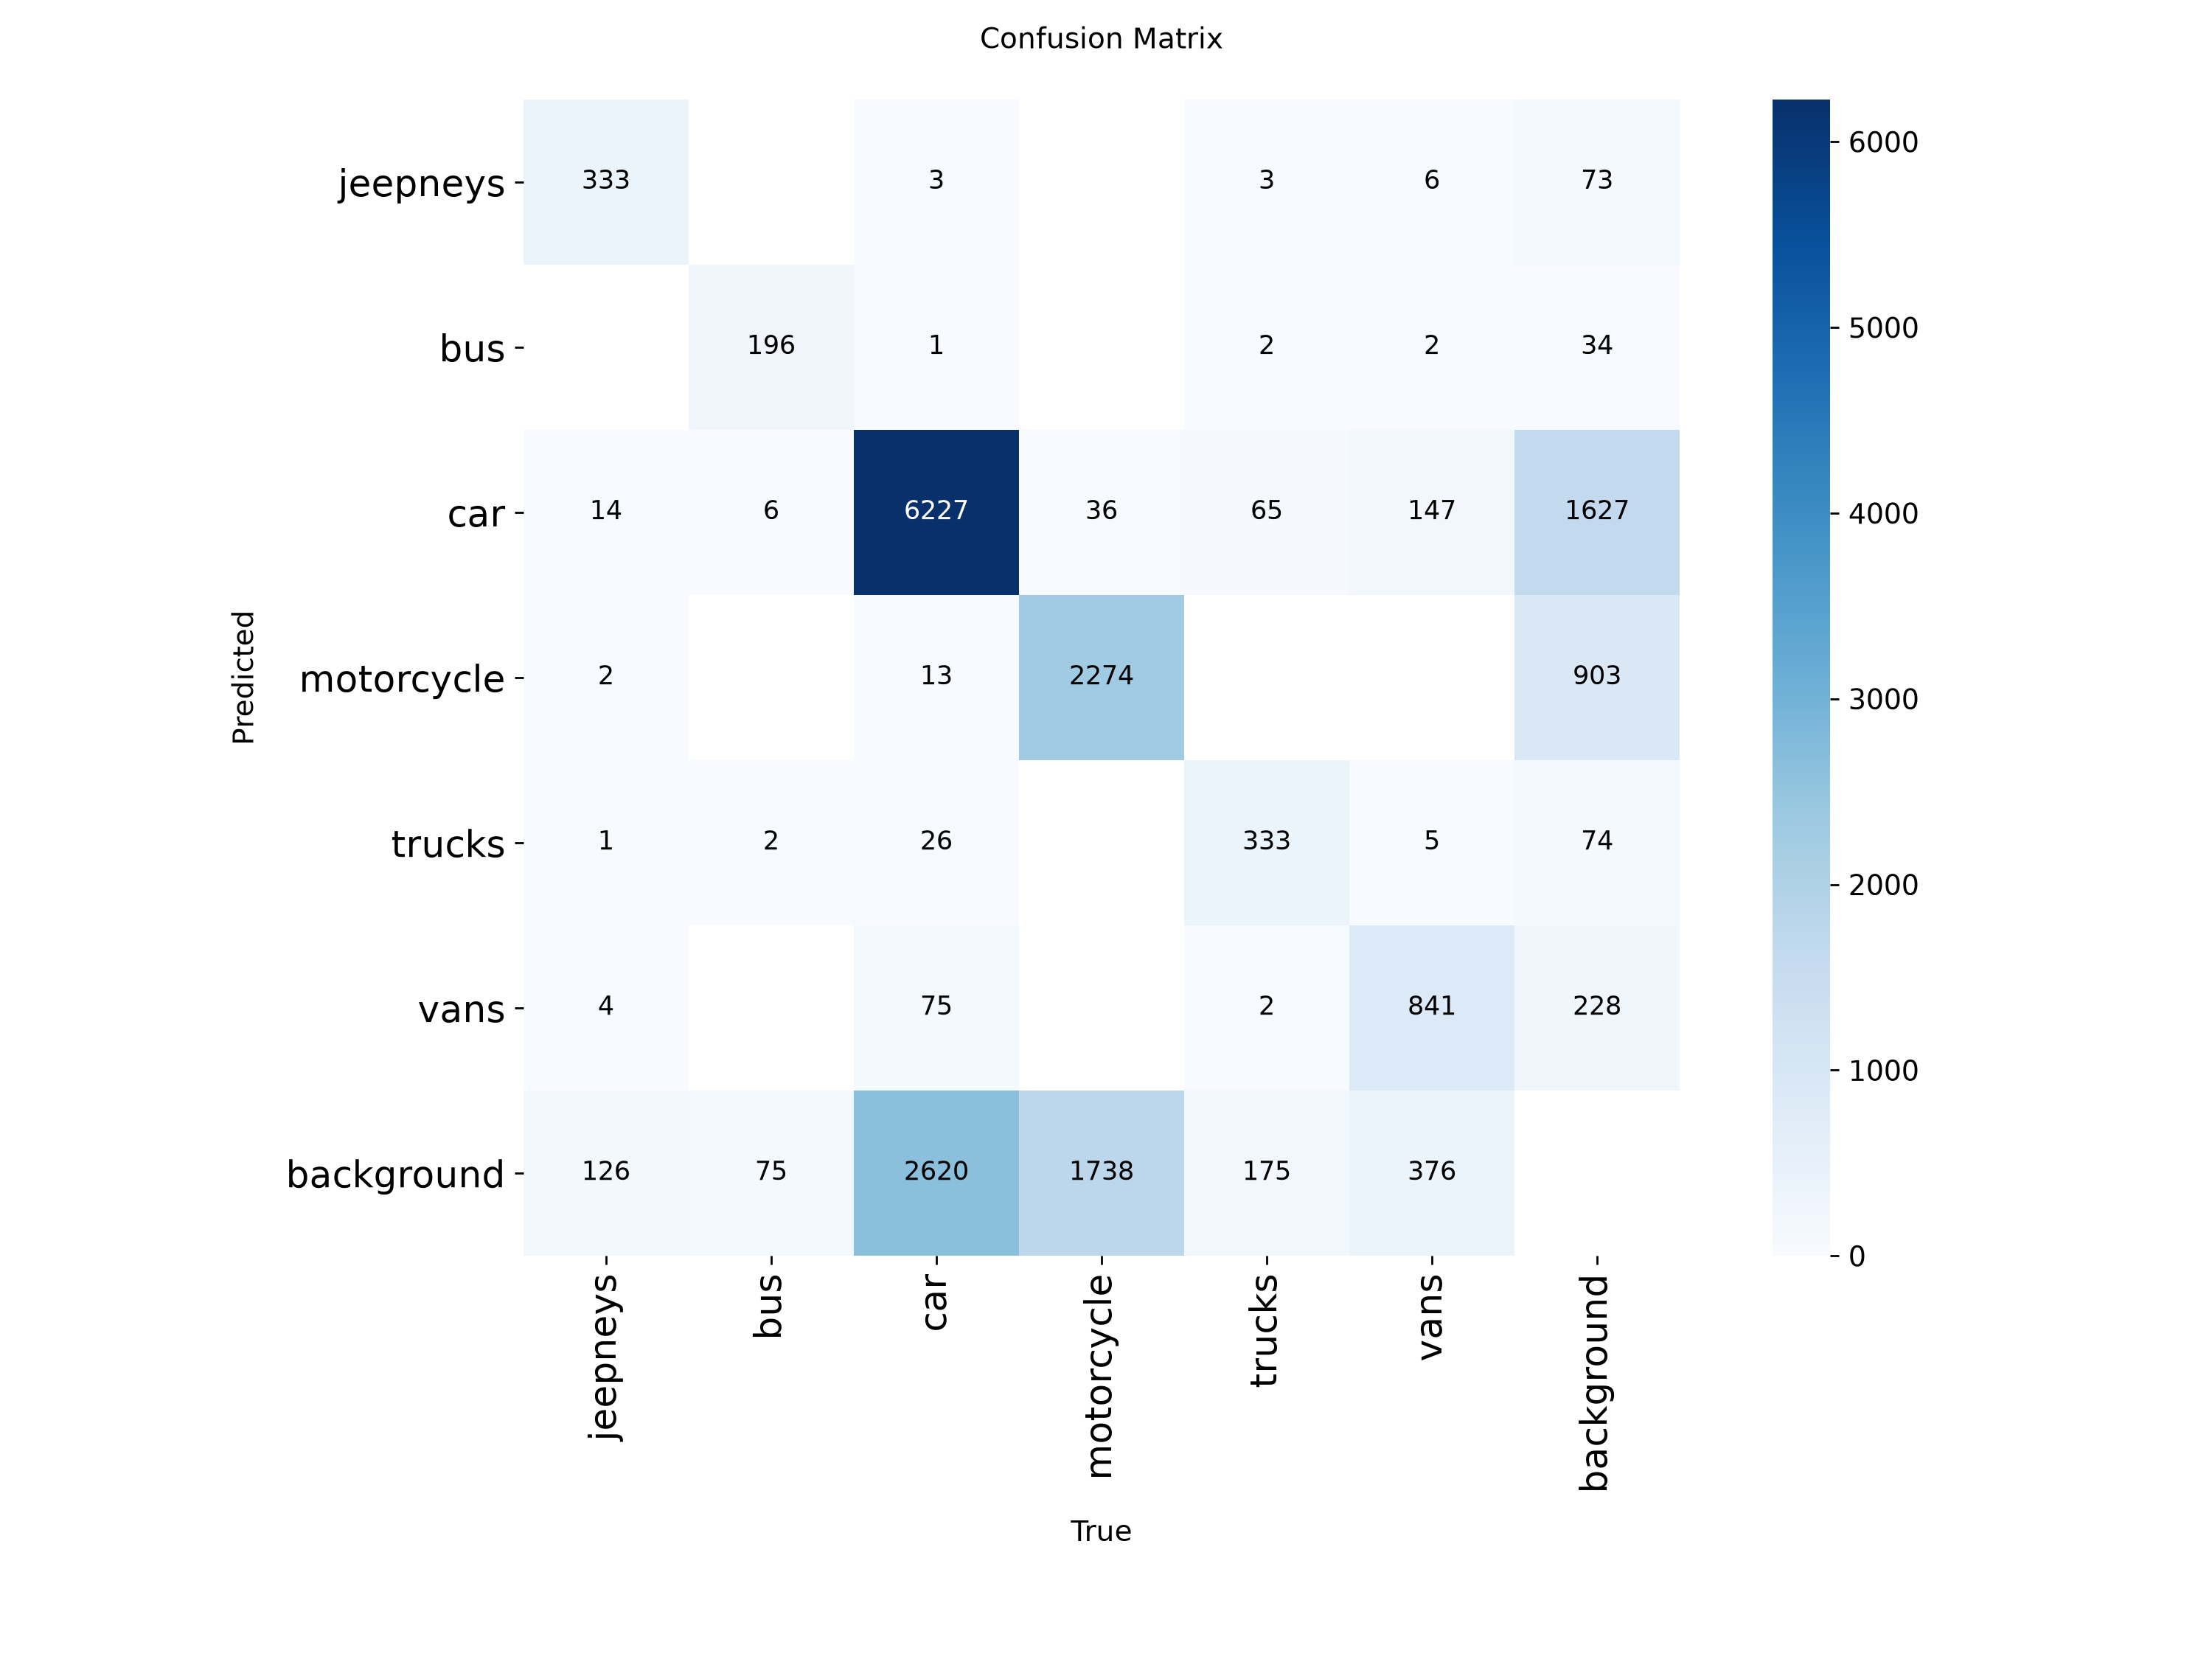

Model B


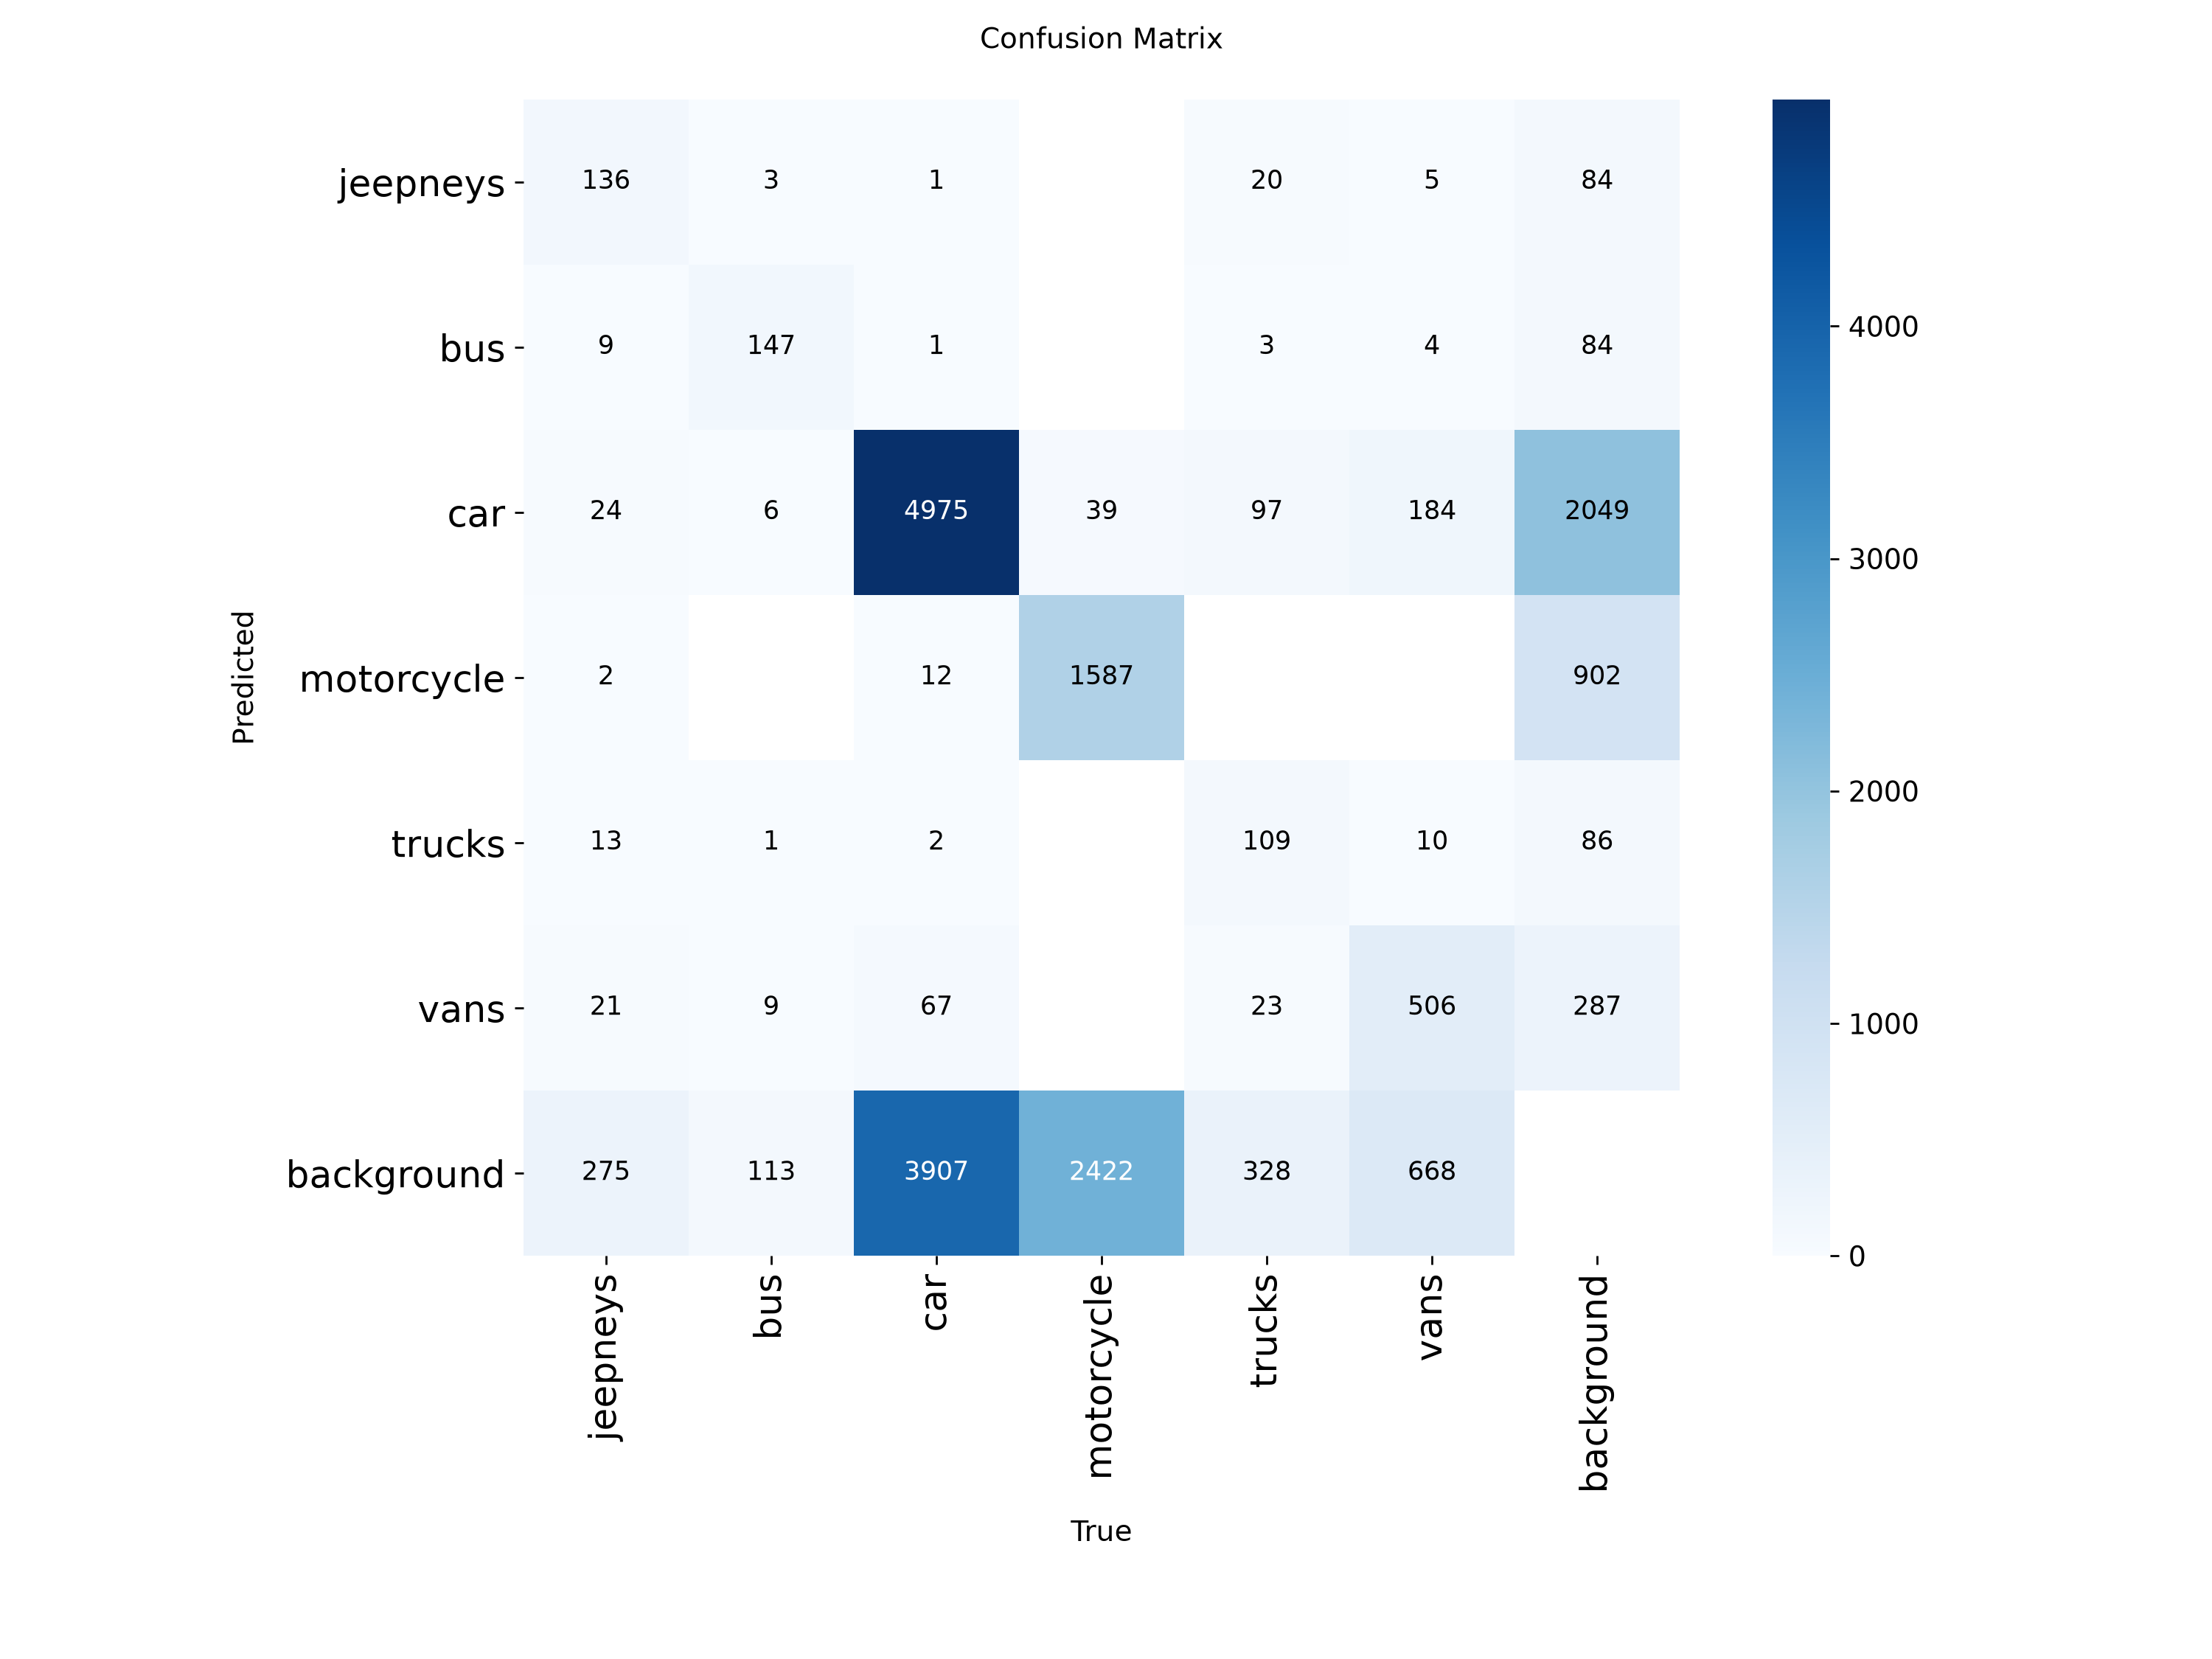

Model C


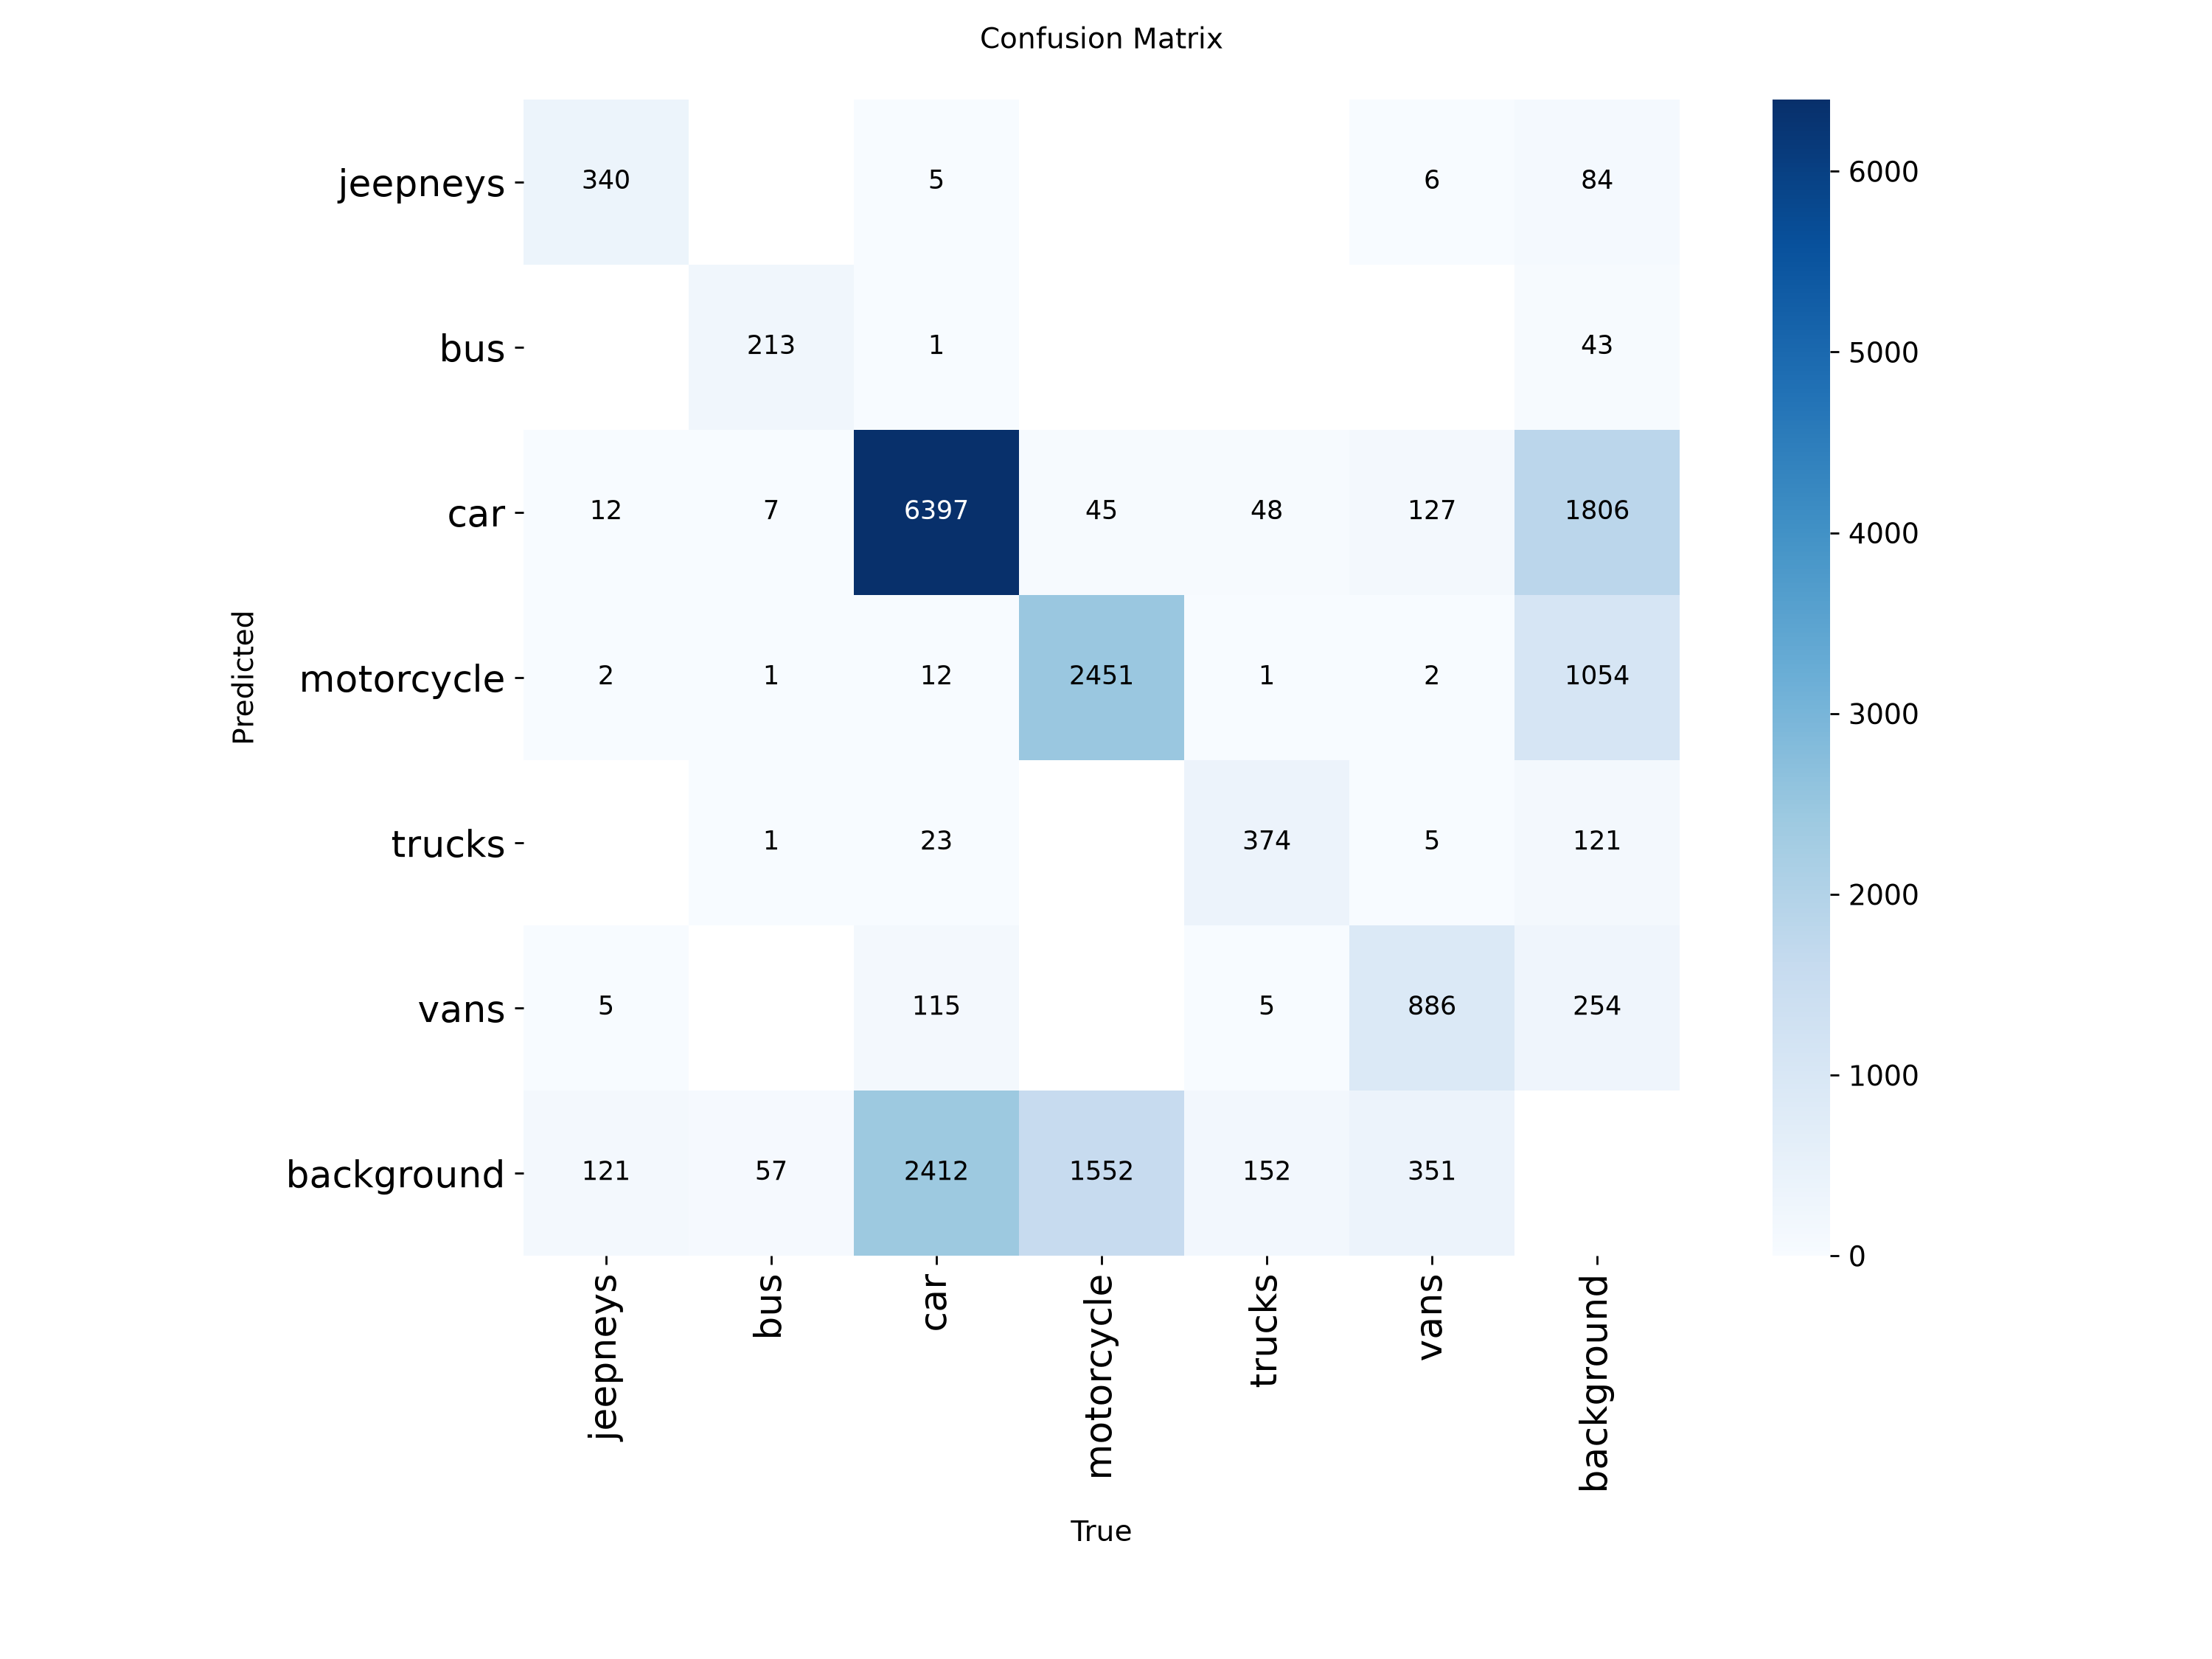

In [29]:
from IPython.display import Image, display

runs = {
    "Model A": r"C:\Users\Arjun\Documents\yolo_vehicle_project\outputs\model_A\confusion_matrix.png",
    "Model B": r"C:\Users\Arjun\Documents\yolo_vehicle_project\outputs\model_B\confusion_matrix.png",
    "Model C": r"C:\Users\Arjun\Documents\yolo_vehicle_project\outputs\model_C\confusion_matrix.png",
}

for name, path in runs.items():
    print(name)
    display(Image(filename=path))

In [33]:
import pandas as pd

for name, folder in [("Model A","model_A"), ("Model B","model_B"), ("Model C","model_C")]:
    csv_path = rf"C:\Users\Arjun\Documents\yolo_vehicle_project\outputs\{folder}\results.csv"
    df = pd.read_csv(csv_path)
    print(f"--- {name}: Final Epoch ---")
    print(df.tail(1).to_string(index=False))
    print()

--- Model A: Final Epoch ---
 epoch    time  train/box_loss  train/cls_loss  train/dfl_loss  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss   lr/pg0   lr/pg1   lr/pg2
    25 3016.51         1.50942         1.02854         0.00376               0.75305            0.66236           0.72345              0.49526       1.37134       1.01927       0.00362 0.000496 0.000496 0.000496

--- Model B: Final Epoch ---
 epoch    time  train/box_loss  train/cls_loss  train/dfl_loss  metrics/precision(B)  metrics/recall(B)  metrics/mAP50(B)  metrics/mAP50-95(B)  val/box_loss  val/cls_loss  val/dfl_loss   lr/pg0   lr/pg1   lr/pg2
    30 1191.34         1.61074         1.59342         0.00384               0.54006            0.45274           0.46059              0.30987       1.45648       1.74605       0.00374 0.000043 0.000043 0.000043

--- Model C: Final Epoch ---
 epoch    time  train/box_loss  train/cls_loss  train/dfl_loss 